In [57]:
# Prediction Test based on Regression and Tree based method

In [58]:
import pandas as pd

# Load the datasets
df_044 = pd.read_csv("mnt-oficial-IJ-044.csv")
df_046 = pd.read_csv("mnt-oficial-IJ-046.csv")
df_117 = pd.read_csv("mnt-oficial-IJ-117.csv")
df_118 = pd.read_csv("mnt-oficial-IJ-118.csv")
df_119 = pd.read_csv("mnt-oficial-IJ-119.csv")
df_120 = pd.read_csv("mnt-oficial-IJ-120.csv")
df_121 = pd.read_csv("mnt-oficial-IJ-121.csv")
df_122 = pd.read_csv("mnt-oficial-IJ-122.csv")

# Concatenate the datasets vertically
merged_df = pd.concat(
    [df_044, df_046, df_117, df_118, df_119, df_120, df_121, df_122], ignore_index=True
)

# Display the first 5 rows
print(merged_df.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types
print(merged_df.info())

| Cód. Ordem   | Cód. Recurso   | Cód. Produto   | Qtd. Produzida   | Qtd. Refugada   | Qtd. Retrabalhada   | Fator Un.   | Cód. Un.   | Descrição da massa (Composto)   | Consumo de massa no item em (Kg/100pçs)   | Qtd. Produzida Acumulada Total   | Qtd. Refugada Acumulada Total   | Qtd. Retrabalhada Acumulada Total   | Fator Un. Acumulado Total   | Consumo de massa no item em (Kg/100pçs) Acumulado Total   | Manutencao   |
|:-------------|:---------------|:---------------|:-----------------|:----------------|:--------------------|:------------|:-----------|:--------------------------------|:------------------------------------------|:---------------------------------|:--------------------------------|:------------------------------------|:----------------------------|:----------------------------------------------------------|:-------------|
| 2680830      | IJ-044         | SA08395        | 868              | 21              | 0                   | 3           | PC         | N-142/67 

In [59]:
# Get all unique values from `Cód. Recurso`
unique_values = merged_df["Cód. Recurso"].unique()

# Check the number of unique values in `Cód. Recurso`
if len(unique_values) > 50:
    # If there are too many unique values, sample the top 50
    top_occuring_values = (
        merged_df["Cód. Recurso"].value_counts().head(50).index.tolist()
    )
    print(top_occuring_values)
else:
    # Otherwise print all unique valus in `Cód. Recurso`
    print(unique_values)

['IJ-044' 'IJ-046' 'IJ-117' 'IJ-118' 'IJ-119' 'IJ-120' 'IJ-121' 'IJ-122']


In [60]:
# Get all unique values from `Cód. Produto`
unique_values = merged_df["Cód. Produto"].unique()

# Check the number of unique values in `Cód. Produto`
if len(unique_values) > 50:
    # If there are too many unique values, sample the top 50
    top_occuring_values = (
        merged_df["Cód. Produto"].value_counts().head(50).index.tolist()
    )
    print(top_occuring_values)
else:
    # Otherwise print all unique valus in `Cód. Produto`
    print(unique_values)

# Get all unique values from `Descrição da massa (Composto)`
unique_values = merged_df["Descrição da massa (Composto)"].unique()

# Check the number of unique values in `Descrição da massa (Composto)`
if len(unique_values) > 50:
    # If there are too many unique values, sample the top 50
    top_occuring_values = (
        merged_df["Descrição da massa (Composto)"]
        .value_counts()
        .head(50)
        .index.tolist()
    )
    print(top_occuring_values)
else:
    # Otherwise print all unique valus in `Descrição da massa (Composto)`
    print(unique_values)

['SA04416', 'SA07320', 'SA07284', 'SA02794', 'SA05883', 'SA02930', 'SA01923', 'SA02961', 'SA07373', 'SA02693', 'SA02938', 'SA05780', 'SA05881', 'SA08457', 'SA01974', 'SA07337', 'SA17439', 'SA02020', 'SA02009', 'SA07321', 'SA02990', 'SA07351', 'SA00946', 'SA01917', 'SA02941', 'SA02374', 'SA02201', 'SA05933', 'SA05590', 'SA05032', 'SA05580', 'SA02844', 'SA02142', 'SA04247', 'SA02262', 'SA07021', 'SA02376', 'SA05253', 'SA00803', 'SA07199', 'SA05997', 'SA00436', 'SA05965', 'SA02556', 'SA01535', 'SA08396', 'SA02008', 'SA07538', 'SA02629', 'SA05061']
['N-142/67' 'N148/18' 'N146/9' 'N-158/3' 'P212/1' 'F420/306' 'F403/32'
 'F420/96' 'F420/191' 'F424/85' 'P248/40' 'F420/95' 'F420/134' 'F424/40 '
 'F424/40' 'S315/10' 'F420/293' 'S316/2' 'P250/14' 'F444/1' ' F403/32'
 'N144/83' ' F420/191' 'F424/51' 'F424/50' 'F420/201' 'N-142/44' 'N108/17']


In [61]:
# Make a copy of the DataFrame
df_encoded = merged_df.copy()

# Apply one-hot encoding to the non-numeric columns
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["Cód. Produto", "Descrição da massa (Composto)", "Cód. Recurso"],
)

# Display the first 5 rows of the transformed DataFrame
print(df_encoded.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types of the transformed DataFrame
print(df_encoded.info())

| Cód. Ordem   | Qtd. Produzida   | Qtd. Refugada   | Qtd. Retrabalhada   | Fator Un.   | Cód. Un.   | Consumo de massa no item em (Kg/100pçs)   | Qtd. Produzida Acumulada Total   | Qtd. Refugada Acumulada Total   | Qtd. Retrabalhada Acumulada Total   | Fator Un. Acumulado Total   | Consumo de massa no item em (Kg/100pçs) Acumulado Total   | Manutencao   | Cód. Produto_10436   | Cód. Produto_11974   | Cód. Produto_12139   | Cód. Produto_12693   | Cód. Produto_12973   | Cód. Produto_13444   | Cód. Produto_15570   | Cód. Produto_15958   | Cód. Produto_17395   | Cód. Produto_18433   | Cód. Produto_18454   | Cód. Produto_27298   | Cód. Produto_SA00013   | Cód. Produto_SA00049   | Cód. Produto_SA00063   | Cód. Produto_SA00181   | Cód. Produto_SA00224   | Cód. Produto_SA00228   | Cód. Produto_SA00272   | Cód. Produto_SA00421   | Cód. Produto_SA00436   | Cód. Produto_SA00484   | Cód. Produto_SA00497   | Cód. Produto_SA00498   | Cód. Produto_SA00501   | Cód. Produto_SA00504   | Cód. Produto_SA

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Drop the `Manutencao` column for the target variable
y = df_encoded["Manutencao"]

# Drop the remaining non-numeric columns and the target variable
X = df_encoded.drop(columns=["Manutencao", "Cód. Un."])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Print the model's score
print("Model score:", model.score(X_test, y_test))

Model score: 0.9851673494016067


In [64]:
# Convert `Cód. Produto` and `Descrição da massa (Composto)` to string type
merged_df["Cód. Produto"] = merged_df["Cód. Produto"].astype(str)
merged_df["Descrição da massa (Composto)"] = merged_df[
    "Descrição da massa (Composto)"
].astype(str)

# Print the column names and their data types
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2432 entries, 0 to 2431
Data columns (total 16 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Cód. Ordem                                               2432 non-null   int64  
 1   Cód. Recurso                                             2432 non-null   object 
 2   Cód. Produto                                             2432 non-null   object 
 3   Qtd. Produzida                                           2432 non-null   int64  
 4   Qtd. Refugada                                            2432 non-null   int64  
 5   Qtd. Retrabalhada                                        2432 non-null   int64  
 6   Fator Un.                                                2432 non-null   int64  
 7   Cód. Un.                                                 2432 non-null   object 
 8   Descrição da massa (Composto

In [65]:
# Apply one-hot encoding to the non-numeric columns
df = pd.get_dummies(
    merged_df,
    columns=[
        "Cód. Produto",
        "Descrição da massa (Composto)",
        "Cód. Recurso",
    ],
)

# Display the first 5 rows of the transformed DataFrame
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types of the transformed DataFrame
print(df.info())

| Cód. Ordem   | Qtd. Produzida   | Qtd. Refugada   | Qtd. Retrabalhada   | Fator Un.   | Cód. Un.   | Consumo de massa no item em (Kg/100pçs)   | Qtd. Produzida Acumulada Total   | Qtd. Refugada Acumulada Total   | Qtd. Retrabalhada Acumulada Total   | Fator Un. Acumulado Total   | Consumo de massa no item em (Kg/100pçs) Acumulado Total   | Manutencao   | Cód. Produto_10436   | Cód. Produto_11974   | Cód. Produto_12139   | Cód. Produto_12693   | Cód. Produto_12973   | Cód. Produto_13444   | Cód. Produto_15570   | Cód. Produto_15958   | Cód. Produto_17395   | Cód. Produto_18433   | Cód. Produto_18454   | Cód. Produto_27298   | Cód. Produto_SA00013   | Cód. Produto_SA00049   | Cód. Produto_SA00063   | Cód. Produto_SA00181   | Cód. Produto_SA00224   | Cód. Produto_SA00228   | Cód. Produto_SA00272   | Cód. Produto_SA00421   | Cód. Produto_SA00436   | Cód. Produto_SA00484   | Cód. Produto_SA00497   | Cód. Produto_SA00498   | Cód. Produto_SA00501   | Cód. Produto_SA00504   | Cód. Produto_SA

In [66]:
# Drop the `Manutencao` column for the target variable
y = df["Manutencao"]

# Drop the remaining non-numeric columns and the target variable
X = df.drop(columns=["Manutencao", "Cód. Un."])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
import numpy as np

X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

X_test = X_test.to_numpy()
y_test = y_test.to_numpy()

In [68]:
# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Print the model's score
print("Model score:", model.score(X_test, y_test))

Model score: 0.9851673494016067


In [69]:
print("Model score:", model.score(X_train, y_train))

Model score: 0.9935526970887113


In [70]:
for i in range(10):
    random_number = np.random.randint(0, len(X_train))
    prediction = model.predict(X_train[random_number].reshape(1, -1))
    print(f"""Modelo: {prediction}, Real: {y_train[random_number].reshape(-1)}""")

Modelo: [238.64987826], Real: [228]
Modelo: [83.91438094], Real: [77]
Modelo: [78.17576201], Real: [77]
Modelo: [107.15436422], Real: [107]
Modelo: [239.20286223], Real: [237]
Modelo: [166.20295911], Real: [164]
Modelo: [198.52308653], Real: [202]
Modelo: [167.02859777], Real: [165]
Modelo: [100.91332138], Real: [108]
Modelo: [118.4481572], Real: [118]


In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

Training and evaluating Random Forest...
Training and evaluating Decision Tree...
Training and evaluating XGBoost...

Model Comparison:
Random Forest:
  MSE: 11.5044
  R-squared: 0.9990
Decision Tree:
  MSE: 12.4271
  R-squared: 0.9989
XGBoost:
  MSE: 9.0767
  R-squared: 0.9992


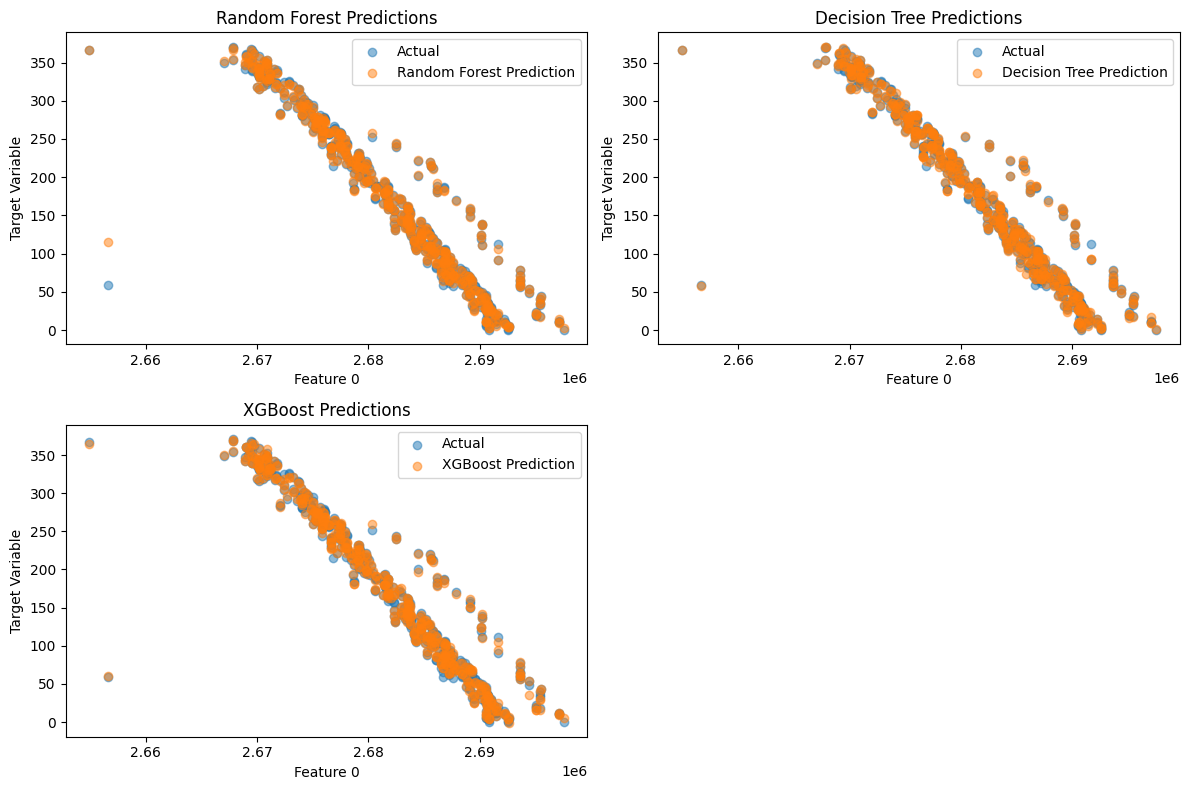

In [72]:
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(
        random_state=42, objective="reg:squarederror"
    ),  # Important for regression
}

results = {}

for name, model in models.items():
    print(f"Training and evaluating {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"model": model, "mse": mse, "r2": r2, "y_pred": y_pred}

# Compare the models
print("\nModel Comparison:")
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  MSE: {metrics['mse']:.4f}")
    print(f"  R-squared: {metrics['r2']:.4f}")

# Plotting:
plt.figure(figsize=(12, 8))
for i, (name, metrics) in enumerate(results.items()):
    plt.subplot(2, 2, i + 1)
    plt.scatter(X_test[:, 0], y_test, label="Actual", alpha=0.5)  # Use array indexing
    plt.scatter(
        X_test[:, 0], metrics["y_pred"], label=name + " Prediction", alpha=0.5
    )  # Use array indexing
    plt.xlabel("Feature 0")  # Or a more descriptive name if you know it
    plt.ylabel("Target Variable")
    plt.title(name + " Predictions")
    plt.legend()
plt.tight_layout()
plt.show()

In [73]:
# Example: Accessing the best model (based on R-squared)
best_model_name = max(results, key=lambda k: results[k]["r2"])
best_model = results[best_model_name]["model"]

print(f"\nBest Model: {best_model_name}")


Best Model: XGBoost


In [74]:
# Find the best model based on a chosen metric (e.g., R-squared)
best_model_name = max(results, key=lambda k: results[k]["r2"])
best_model_metrics = results[best_model_name]
# Print the best model's metrics
print(f"\nBest Model: {best_model_name}")
print("Metrics for the best model:")
for metric_name, metric_value in best_model_metrics.items():
    if metric_name != "model":  # Exclude the model object itself
        print(f"  {metric_name}: {metric_value}")


Best Model: XGBoost
Metrics for the best model:
  mse: 9.076658264742065
  r2: 0.9991755485534668
  y_pred: [113.782074     3.7019563  258.55304     75.792725    19.291529
 181.5844      21.389658   108.13632    330.14987    133.69867
 207.7275     289.0642      16.059711    13.977041   109.77427
   5.877147   162.50252    139.13388    264.83533    292.48282
 196.67365    293.44702     75.131714   183.31749     11.784785
 273.7389     259.16037    319.1772     104.94397    193.8949
  34.366234   116.50461     86.71154     75.85347    225.5408
 121.68816    148.52072    125.059586   348.4633      43.444664
 161.42973    214.69304    266.41397    196.8348     235.37396
 339.82504    253.94519    350.90936     78.97202    303.18607
 131.674      215.32953    320.3026     221.68901      7.249278
 139.07362     37.34137     74.89355    138.65068    190.8504
  77.60436    127.05019    360.4927     112.24115    105.23375
  43.272602    42.776947   256.24826    235.9294     154.00363
 173.496

In [75]:
for name, model_data in results.items():
    model = model_data["model"]
    predictions = model.predict(X_train)
    print(f"\nPredictions using {name} on random data:")
    print(predictions)


Predictions using Random Forest on random data:
[ 76.5   73.9  324.49 ...  31.53 206.62 351.95]

Predictions using Decision Tree on random data:
[ 77.  73. 327. ...  32. 206. 352.]

Predictions using XGBoost on random data:
[ 76.46936   75.90217  324.68292  ...  31.163788 206.32513  350.378   ]


In [76]:
print(y_train)

[ 77  73 327 ...  32 206 352]


In [77]:
for name, model_data in results.items():
    model = model_data["model"]
    predictions = model.predict(X_test[:50])
    print(f"\nPredictions using {name} on random data:")
    print(predictions)


Predictions using Random Forest on random data:
[110.66   3.85 260.69  71.5   20.56 182.48  23.23 109.58 328.38 130.68
 204.76 291.51  19.24  13.92 111.7    6.55 161.54 137.64 261.51 291.54
 192.5  293.04  71.97 183.02  14.21 270.84 257.3  317.74 104.08 194.37
  34.22 114.98  83.76  72.26 226.6  119.48 147.06 130.05 353.7   43.27
 159.29 215.37 267.04 202.69 239.37 343.58 255.18 351.96  79.53 302.97]

Predictions using Decision Tree on random data:
[112.   3. 261.  72.  23. 180.  27. 109. 331. 132. 206. 296.  16.  13.
 109.   7. 163. 136. 265. 293. 196. 293.  72. 180.  17. 273. 258. 318.
 104. 194.  28. 113.  85.  75. 227. 116. 144. 129. 355.  43. 160. 214.
 265. 202. 240. 345. 257. 351.  79. 303.]

Predictions using XGBoost on random data:
[113.782074    3.7019563 258.55304    75.792725   19.291529  181.5844
  21.389658  108.13632   330.14987   133.69867   207.7275    289.0642
  16.059711   13.977041  109.77427     5.877147  162.50252   139.13388
 264.83533   292.48282   196.67365   

In [78]:
y_test[:50]

array([111,   2, 262,  68,  13, 179,  21, 108, 326, 131, 206, 295,  19,
        13, 110,   8, 162, 137, 264, 290, 195, 292,  73, 181,  12, 271,
       259, 317, 105, 193,  30, 114,  83,  74, 228, 121, 148, 131, 354,
        44, 159, 213, 265, 201, 236, 340, 256, 352,  80, 301])

In [79]:
import pandas as pd
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)  # Added GradientBoosting
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [80]:
# 1. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [81]:
# 2. Random Forest (as you had before, but I'll include it for comparison)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# Feature importance
tree_models = {
    "Decision Tree Regression": DecisionTreeRegressor(random_state=42),
    "Random Forest Regression": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regression": GradientBoostingRegressor(random_state=42),
}
for model_name, model in tree_models.items():
    model.fit(X_train, y_train)
    importance = model.feature_importances_
    print(f"{model_name} - Feature Importance:")
    for i, feature_name in enumerate(X.columns):
        print(f"{feature_name}: {importance[i]:.4f}")

Decision Tree Regression - Feature Importance:
Cód. Ordem: 0.8578
Qtd. Produzida: 0.0001
Qtd. Refugada: 0.0001
Qtd. Retrabalhada: 0.0000
Fator Un.: 0.0000
Consumo de massa no item em (Kg/100pçs): 0.0001
Qtd. Produzida Acumulada Total: 0.0059
Qtd. Refugada Acumulada Total: 0.0096
Qtd. Retrabalhada Acumulada Total: 0.0000
Fator Un. Acumulado Total: 0.1234
Consumo de massa no item em (Kg/100pçs) Acumulado Total: 0.0010
Cód. Produto_10436: 0.0000
Cód. Produto_11974: 0.0000
Cód. Produto_12139: 0.0000
Cód. Produto_12693: 0.0000
Cód. Produto_12973: 0.0000
Cód. Produto_13444: 0.0000
Cód. Produto_15570: 0.0000
Cód. Produto_15958: 0.0000
Cód. Produto_17395: 0.0000
Cód. Produto_18433: 0.0000
Cód. Produto_18454: 0.0000
Cód. Produto_27298: 0.0000
Cód. Produto_SA00013: 0.0000
Cód. Produto_SA00049: 0.0000
Cód. Produto_SA00063: 0.0000
Cód. Produto_SA00181: 0.0000
Cód. Produto_SA00224: 0.0000
Cód. Produto_SA00228: 0.0000
Cód. Produto_SA00272: 0.0000
Cód. Produto_SA00421: 0.0000
Cód. Produto_SA00436: 0.

In [84]:
def evaluate_model(model, y_true, y_pred, y_prob, model_name):
    print(f"--- {model_name} Evaluation ---")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})"
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=np.unique(y),
        yticklabels=np.unique(y),
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # Classification Report
    print(classification_report(y_true, y_pred))

    # Cross-validation (example for Random Forest, adapt as needed)
    if model_name == "Random Forest":  # Only do CV for RF in this example
        kfold = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(
            model, X_train, y_train, cv=kfold, scoring="accuracy"
        )
        print("Cross-validation scores:", cv_scores)
        print("Mean CV accuracy:", cv_scores.mean())

In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)


def evaluate_model(model, y_true, y_pred, y_prob, model_name):
    """Evaluates a classification model and prints the results."""

    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    if y_prob is not None:
        print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\n")

In [89]:
# Define and train models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Define evaluate_model function (as shown earlier)

# Evaluate all models
evaluate_model(dt_model, y_test, y_pred_dt, y_prob_dt, "Decision Tree")

KeyboardInterrupt: 

In [ ]:
evaluate_model(rf_model, y_test, y_pred_rf, y_prob_rf, "Random Forest")

In [ ]:
evaluate_model(gb_model, y_test, y_pred_gb, y_prob_gb, "Gradient Boosting")

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = merged_df[
    [
        "Qtd. Produzida",
        "Qtd. Refugada",
        "Qtd. Retrabalhada",
        "Fator Un.",
        "Consumo de massa no item em (Kg/100pçs)",
    ]
]
y = merged_df["Manutencao"]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display the shapes of the train and test sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Initialize the models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor(random_state=42),
    "Random Forest Regression": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regression": GradientBoostingRegressor(random_state=42),
}

# Train and predict with each model
predictions = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

# Evaluate each model using RMSE
rmse_results = {}
for model_name, y_pred in predictions.items():
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    rmse_results[model_name] = rmse

# Display the RMSE results
for model_name, rmse in rmse_results.items():
    print(f"{model_name} RMSE: {rmse}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Residual plots
for model_name, y_pred in predictions.items():
    plt.figure()
    plt.scatter(y_pred, y_test - y_pred)
    plt.title(f"{model_name} - Residual Plot")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.show()

In [ ]:
# Feature importance
tree_models = {
    "Decision Tree Regression": DecisionTreeRegressor(random_state=42),
    "Random Forest Regression": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regression": GradientBoostingRegressor(random_state=42),
}
for model_name, model in tree_models.items():
    model.fit(X_train, y_train)
    importance = model.feature_importances_
    print(f"{model_name} - Feature Importance:")
    for i, feature_name in enumerate(X.columns):
        print(f"{feature_name}: {importance[i]:.4f}")